# Understanding the 6-Plot

The **6-Plot** extends the 4-Plot by adding two additional panels for the **two-sample problem**: a scatter plot and a linear fit. The full 6-Plot is a 2×3 grid testing whether two datasets share the same process, or comparing a dataset against a model. uses it when you have both a response variable and a predictor (regression context).

| Panel | What it tests |
|---|---|
| ① Run Sequence Plot | Fixed location + variation |
| ② Lag Plot | Randomness (independence) |
| ③ Histogram | Fixed distribution shape |
| ④ Normal Probability Plot | Normality |
| ⑤ Scatter Plot (y vs x) | Relationship between variables |
| ⑥ Residual Plot | Adequacy of the fitted model |

In practice the 6-Plot is run on regression residuals: panels ①–④ diagnose the residuals, panel ⑤ shows the raw relationship, and panel ⑥ shows residuals vs fitted values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

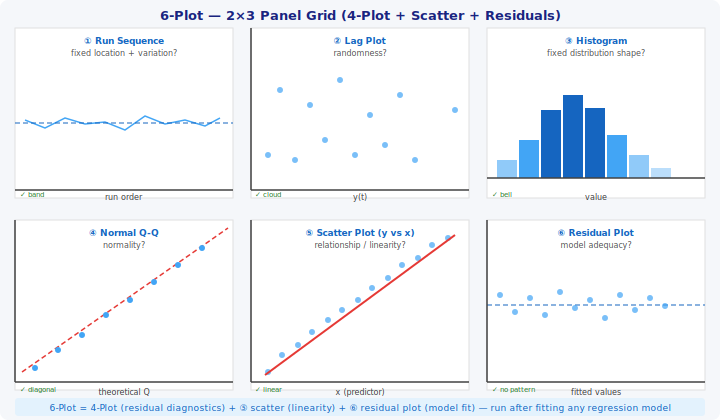

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="420"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="420" fill="#F5F7FA" rx="8"/>
  <text x="360" y="20" text-anchor="middle" font-size="13" font-weight="bold"
        fill="#1A237E">6-Plot — 2×3 Panel Grid (4-Plot + Scatter + Residuals)</text>

  <!-- ── PANEL ① Run Sequence ── -->
  <rect x="15" y="28" width="218" height="170" fill="white" stroke="#E0E0E0"/>
  <text x="124" y="44" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">① Run Sequence</text>
  <text x="124" y="56" text-anchor="middle" font-size="8" fill="#555">fixed location + variation?</text>
  <polyline points="25,120 45,128 65,118 85,124 105,122 125,130 145,116 165,124 185,120 205,126 220,118"
            fill="none" stroke="#42A5F5" stroke-width="1.5"/>
  <line x1="15" y1="123" x2="233" y2="123" stroke="#1565C0" stroke-width="1" stroke-dasharray="5,3"/>
  <line x1="15" y1="190" x2="233" y2="190" stroke="#424242" stroke-width="1.5"/>
  <text x="124" y="200" text-anchor="middle" font-size="8" fill="#424242">run order</text>
  <text x="20" y="197" font-size="7" fill="#2E7D32">✓ band</text>

  <!-- ── PANEL ② Lag Plot ── -->
  <rect x="251" y="28" width="218" height="170" fill="white" stroke="#E0E0E0"/>
  <text x="360" y="44" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">② Lag Plot</text>
  <text x="360" y="56" text-anchor="middle" font-size="8" fill="#555">randomness?</text>
  <circle cx="268" cy="155" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="280" cy="90"  r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="295" cy="160" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="310" cy="105" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="325" cy="140" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="340" cy="80"  r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="355" cy="155" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="370" cy="115" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="385" cy="145" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="400" cy="95"  r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="415" cy="160" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="455" cy="110" r="3" fill="#42A5F5" opacity="0.7"/>
  <line x1="251" y1="190" x2="469" y2="190" stroke="#424242" stroke-width="1.5"/>
  <line x1="251" y1="190" x2="251" y2="28"  stroke="#424242" stroke-width="1.5"/>
  <text x="360" y="200" text-anchor="middle" font-size="8" fill="#424242">y(t)</text>
  <text x="255" y="197" font-size="7" fill="#2E7D32">✓ cloud</text>

  <!-- ── PANEL ③ Histogram ── -->
  <rect x="487" y="28" width="218" height="170" fill="white" stroke="#E0E0E0"/>
  <text x="596" y="44" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">③ Histogram</text>
  <text x="596" y="56" text-anchor="middle" font-size="8" fill="#555">fixed distribution shape?</text>
  <rect x="497" y="160" width="20" height="18" fill="#90CAF9"/>
  <rect x="519" y="140" width="20" height="38" fill="#42A5F5"/>
  <rect x="541" y="110" width="20" height="68" fill="#1565C0"/>
  <rect x="563" y="95"  width="20" height="83" fill="#1565C0"/>
  <rect x="585" y="108" width="20" height="70" fill="#1565C0"/>
  <rect x="607" y="135" width="20" height="43" fill="#42A5F5"/>
  <rect x="629" y="155" width="20" height="23" fill="#90CAF9"/>
  <rect x="651" y="168" width="20" height="10" fill="#BBDEFB"/>
  <line x1="487" y1="178" x2="705" y2="178" stroke="#424242" stroke-width="1.5"/>
  <text x="596" y="200" text-anchor="middle" font-size="8" fill="#424242">value</text>
  <text x="492" y="197" font-size="7" fill="#2E7D32">✓ bell</text>

  <!-- ── PANEL ④ Normal Q-Q ── -->
  <rect x="15" y="220" width="218" height="170" fill="white" stroke="#E0E0E0"/>
  <text x="124" y="236" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">④ Normal Q-Q</text>
  <text x="124" y="248" text-anchor="middle" font-size="8" fill="#555">normality?</text>
  <line x1="22" y1="372" x2="228" y2="228" stroke="#E53935" stroke-width="1.5" stroke-dasharray="5,3"/>
  <circle cx="35"  cy="368" r="3" fill="#42A5F5"/>
  <circle cx="58"  cy="350" r="3" fill="#42A5F5"/>
  <circle cx="82"  cy="335" r="3" fill="#42A5F5"/>
  <circle cx="106" cy="315" r="3" fill="#42A5F5"/>
  <circle cx="130" cy="300" r="3" fill="#42A5F5"/>
  <circle cx="154" cy="282" r="3" fill="#42A5F5"/>
  <circle cx="178" cy="265" r="3" fill="#42A5F5"/>
  <circle cx="202" cy="248" r="3" fill="#42A5F5"/>
  <line x1="15"  y1="382" x2="233" y2="382" stroke="#424242" stroke-width="1.5"/>
  <line x1="15"  y1="382" x2="15"  y2="220" stroke="#424242" stroke-width="1.5"/>
  <text x="124" y="395" text-anchor="middle" font-size="8" fill="#424242">theoretical Q</text>
  <text x="20" y="392" font-size="7" fill="#2E7D32">✓ diagonal</text>

  <!-- ── PANEL ⑤ Scatter (y vs x) ── -->
  <rect x="251" y="220" width="218" height="170" fill="white" stroke="#E0E0E0"/>
  <text x="360" y="236" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">⑤ Scatter Plot (y vs x)</text>
  <text x="360" y="248" text-anchor="middle" font-size="8" fill="#555">relationship / linearity?</text>
  <!-- scatter with linear trend -->
  <circle cx="268" cy="372" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="282" cy="355" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="298" cy="345" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="312" cy="332" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="328" cy="320" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="342" cy="310" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="358" cy="300" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="372" cy="288" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="388" cy="278" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="402" cy="265" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="418" cy="258" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="432" cy="245" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="448" cy="238" r="3" fill="#42A5F5" opacity="0.7"/>
  <!-- regression line -->
  <line x1="265" y1="375" x2="455" y2="235" stroke="#E53935" stroke-width="2"/>
  <line x1="251" y1="382" x2="469" y2="382" stroke="#424242" stroke-width="1.5"/>
  <line x1="251" y1="382" x2="251" y2="220" stroke="#424242" stroke-width="1.5"/>
  <text x="360" y="395" text-anchor="middle" font-size="8" fill="#424242">x (predictor)</text>
  <text x="255" y="392" font-size="7" fill="#2E7D32">✓ linear</text>

  <!-- ── PANEL ⑥ Residuals ── -->
  <rect x="487" y="220" width="218" height="170" fill="white" stroke="#E0E0E0"/>
  <text x="596" y="236" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">⑥ Residual Plot</text>
  <text x="596" y="248" text-anchor="middle" font-size="8" fill="#555">model adequacy?</text>
  <line x1="487" y1="305" x2="705" y2="305" stroke="#1565C0" stroke-width="1" stroke-dasharray="5,3"/>
  <circle cx="500" cy="295" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="515" cy="312" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="530" cy="298" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="545" cy="315" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="560" cy="292" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="575" cy="308" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="590" cy="300" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="605" cy="318" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="620" cy="295" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="635" cy="310" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="650" cy="298" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="665" cy="306" r="3" fill="#42A5F5" opacity="0.7"/>
  <line x1="487" y1="382" x2="705" y2="382" stroke="#424242" stroke-width="1.5"/>
  <line x1="487" y1="382" x2="487" y2="220" stroke="#424242" stroke-width="1.5"/>
  <text x="596" y="395" text-anchor="middle" font-size="8" fill="#424242">fitted values</text>
  <text x="492" y="392" font-size="7" fill="#2E7D32">✓ no pattern</text>

  <!-- Takeaway -->
  <rect x="15" y="398" width="690" height="18" fill="#E3F2FD" rx="3"/>
  <text x="360" y="411" text-anchor="middle" font-size="9" fill="#1565C0">
    6-Plot = 4-Plot (residual diagnostics) + ⑤ scatter (linearity) + ⑥ residual plot (model fit) — run after fitting any regression model
  </text>
</svg>
"""
display(SVG(_svg))

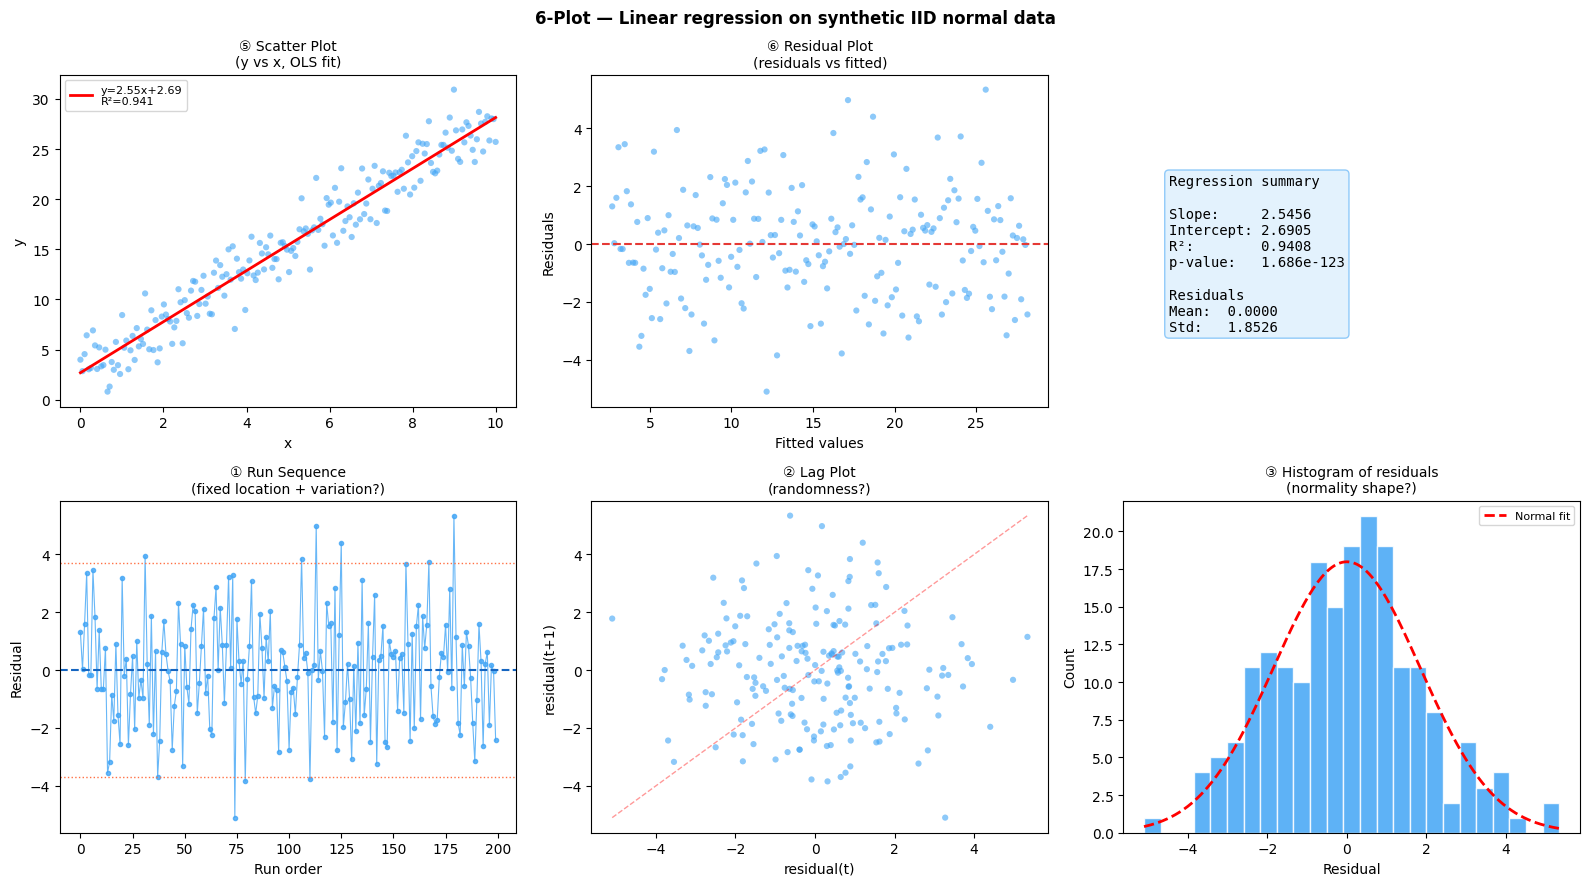

In [3]:
def six_plot(x, y, title="6-Plot"):
    """6-Plot: scatter + OLS fit, then 4-Plot on the residuals."""
    slope, intercept, r_value, p_value, se = stats.linregress(x, y)
    y_hat = slope * x + intercept
    residuals = y - y_hat

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    n = len(residuals)
    idx = np.arange(n)

    # ⑤ Scatter with OLS line (panel 0,0)
    ax = axes[0, 0]
    ax.scatter(x, y, color='#42A5F5', alpha=0.6, s=20, edgecolors='none')
    x_line = np.array([x.min(), x.max()])
    ax.plot(x_line, slope*x_line + intercept, 'r-', linewidth=2,
            label=f'y={slope:.2f}x+{intercept:.2f}\nR²={r_value**2:.3f}')
    ax.set_title('⑤ Scatter Plot\n(y vs x, OLS fit)', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)

    # ⑥ Residuals vs fitted (panel 0,1)
    ax = axes[0, 1]
    ax.scatter(y_hat, residuals, color='#42A5F5', alpha=0.6, s=20, edgecolors='none')
    ax.axhline(0, color='#E53935', linewidth=1.5, linestyle='--')
    ax.set_title('⑥ Residual Plot\n(residuals vs fitted)', fontsize=10)
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Residuals')

    # unused 3rd panel in row 0 — summary text
    axes[0, 2].axis('off')
    mu_r, sig_r = residuals.mean(), residuals.std()
    axes[0, 2].text(0.1, 0.7, f"Regression summary\n\nSlope:     {slope:.4f}\nIntercept: {intercept:.4f}\n"
                    f"R²:        {r_value**2:.4f}\np-value:   {p_value:.4g}\n\n"
                    f"Residuals\nMean:  {mu_r:.4f}\nStd:   {sig_r:.4f}",
                    transform=axes[0, 2].transAxes,
                    fontsize=10, family='monospace', va='top',
                    bbox=dict(facecolor='#E3F2FD', edgecolor='#90CAF9', boxstyle='round'))

    # ① Run Sequence of residuals (panel 1,0)
    ax = axes[1, 0]
    ax.plot(idx, residuals, 'o-', color='#42A5F5', markersize=3, linewidth=0.8, alpha=0.8)
    ax.axhline(0, color='#1565C0', linewidth=1.5, linestyle='--')
    ax.axhline( 2*sig_r, color='#FF7043', linewidth=1, linestyle=':')
    ax.axhline(-2*sig_r, color='#FF7043', linewidth=1, linestyle=':')
    ax.set_title('① Run Sequence\n(fixed location + variation?)', fontsize=10)
    ax.set_xlabel('Run order')
    ax.set_ylabel('Residual')

    # ② Lag Plot of residuals (panel 1,1)
    ax = axes[1, 1]
    ax.scatter(residuals[:-1], residuals[1:], color='#42A5F5', alpha=0.6, s=20, edgecolors='none')
    lo, hi = residuals.min(), residuals.max()
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1, alpha=0.4)
    ax.set_title('② Lag Plot\n(randomness?)', fontsize=10)
    ax.set_xlabel('residual(t)')
    ax.set_ylabel('residual(t+1)')

    # ③ Histogram of residuals (panel 1,2)
    ax = axes[1, 2]
    ax.hist(residuals, bins=25, color='#42A5F5', edgecolor='white', alpha=0.85)
    x_r = np.linspace(residuals.min(), residuals.max(), 200)
    pdf = stats.norm.pdf(x_r, mu_r, sig_r) * n * (residuals.max()-residuals.min()) / 25
    ax.plot(x_r, pdf, 'r--', linewidth=2, label='Normal fit')
    ax.set_title('③ Histogram of residuals\n(normality shape?)', fontsize=10)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

np.random.seed(42)
x = np.linspace(0, 10, 200)
y = 2.5 * x + 3 + np.random.normal(0, 2, 200)

six_plot(x, y, "6-Plot — Linear regression on synthetic IID normal data")

## Key Takeaways

| | |
|---|---|
| **Purpose** | Extends 4-Plot to regression context: diagnose both the model and the residuals |
| **Panels ①–④** | Run on residuals — tests whether OLS assumptions hold |
| **Panel ⑤** | Scatter + fit line — shows linearity and whether a line is appropriate |
| **Panel ⑥** | Residuals vs fitted — reveals heteroscedasticity, curvature, outliers |
| **Good 6-Plot** | Linear scatter; residuals in horizontal band; lag cloud; bell residual histogram; diagonal Q-Q |
| **Fan shape in ⑥** | Heteroscedasticity — variance increases with fitted value → use WLS or transform y |
| **Curve in ⑥** | Non-linearity — add polynomial term or use non-linear model |
| **vs 4-Plot** | 4-Plot = univariate; 6-Plot = regression diagnostics |